# Rotten Tomatoes Movie Ratings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Bringing in the filtered data from
df = pd.read_csv(r"C:\Users\Rosny\Desktop\Movie Ratings Project\filtered_data.csv")
df

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action , Adventure, Comedy, Drama, Science Fic...",12-02-10,06-29-10,83.0,Rotten,49.0,144.0,53.0,254287.0
1,Please Give,R,Comedy,04-30-10,10-19-10,90.0,Certified Fresh,86.0,140.0,64.0,11567.0
2,10,R,"Comedy, Romance",05-10-79,08-27-97,118.0,Fresh,68.0,22.0,53.0,14670.0
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",04-13-57,06-03-01,95.0,Certified Fresh,100.0,51.0,97.0,105000.0
4,"20,000 Leagues Under The Sea",G,"Action , Adventure, Drama, Kids , Family",01-01-54,05-20-03,127.0,Fresh,89.0,27.0,74.0,68860.0
...,...,...,...,...,...,...,...,...,...,...,...
16529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16532,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.dropna(subset=['movie_title'])
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df['genre'] = df['genre'].str.replace(' , ', ' & ')
df.describe()

C:\Users\Rosny\AppData\Local\Temp\ipykernel_23044\3186837892.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['genre'] = df['genre'].str.replace(' , ', ' & ')


,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
count,"16,239.00","16,386.00","16,386.00","16,386.00","16,386.00"
mean,102.56,60.33,57.27,60.47,"152,479.70"
std,25.04,28.59,66.64,20.46,"1,817,736.17"
min,1.00,0.00,5.00,0.00,5.00
25%,90.00,38.00,12.00,45.00,864.25
50%,99.00,66.00,29.00,62.00,"4,876.50"
75%,111.00,85.00,78.00,77.00,"28,752.00"
max,"2,000.00",100.00,497.00,100.00,"35,797,635.00"


In [4]:
df[df["runtime_in_minutes"] == 1]

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
319,The Border,R,"Action & Adventure, Drama, Mystery & Suspense",01-29-82,11-05-04,1.00,Fresh,80.00,10.00,53.00,"3,283.00"
1011,The Prophecy,R,"Horror, Mystery & Suspense, Science Fiction & ...",01-09-95,09-02-99,1.00,Rotten,43.00,23.00,64.00,"29,497.00"
3009,The Barbarian Invasions (Les Invasions barbares),R,"Art House & International, Comedy, Drama",11-21-03,07-13-04,1.00,Certified Fresh,82.00,133.00,89.00,"18,829.00"
6945,Halloween - The Curse of Michael Myers (Hallow...,R,"Horror, Kids & Family",01-06-95,10-10-00,1.00,Rotten,6.00,34.00,37.00,"68,025.00"
7173,Hellraiser: Deader,R,Horror,07-06-05,07-06-05,1.00,Rotten,17.00,6.00,26.00,"13,618.00"
7174,Hellraiser: Hellseeker,R,Horror,10-15-02,10-22-02,1.00,Rotten,0.00,7.00,33.00,"16,445.00"
7175,Hellraiser: Hellworld,R,Horror,06-09-05,06-09-05,1.00,Rotten,20.00,5.00,23.00,"17,647.00"
11820,Rory O'Shea Was Here,R,"Art House & International, Comedy, Drama",04-02-05,06-14-05,1.00,Rotten,49.00,69.00,88.00,"8,755.00"


In [5]:
# Movies that are imported with a runtime of 1 minutes
df.at[319, 'runtime_in_minutes'] = 117
df.at[1011, 'runtime_in_minutes'] = 98
df.at[3009, 'runtime_in_minutes'] = 99
df.at[6945, 'runtime_in_minutes'] = 88
df.at[7173, 'runtime_in_minutes'] = 88
df.at[7174, 'runtime_in_minutes'] = 89
df.at[7175, 'runtime_in_minutes'] = 95
df.at[11820, 'runtime_in_minutes'] = 104

# df.iloc[[319,1011,3009,6945,7173,7174,7175,11820]]

In [6]:
df[df["runtime_in_minutes"] < 15]

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
1782,Blind Date,NR,"Comedy, Drama",09-25-09,12-22-09,14.00,Rotten,33.00,21.00,35.00,504.00
6481,George Lucas in Love,NR,Science Fiction & Fantasy,NaN,11-21-00,8.00,Fresh,78.00,9.00,83.00,"3,836.00"
7012,The Hard Word,R,"Action & Adventure, Art House & International,...",06-13-03,07-10-03,2.00,Rotten,39.00,82.00,40.00,"2,082.00"
7017,Hardware Wars,NR,Comedy,08-09-09,04-23-02,13.00,Fresh,83.00,6.00,68.00,"3,399.00"
9267,Maestro,NR,"Animation, Musical & Performing Arts",01-05-05,07-26-05,5.00,Rotten,38.00,16.00,76.00,246.00
10859,Patch Adams,PG-13,"Comedy, Drama",12-25-98,06-22-99,2.00,Rotten,22.00,68.00,73.00,"265,051.00"
10910,The Penalty,NR,"Classics, Drama, Horror, Mystery & Suspense",01-01-20,08-03-05,6.00,Fresh,80.00,5.00,75.00,523.00
16171,Frau im Mond (By Rocket to the Moon) (Woman in...,NR,"Art House & International, Classics, Comedy, D...",10-15-29,09-11-04,12.00,Fresh,71.00,7.00,72.00,643.00


In [7]:
# Movies with incorrectly imported runtimes under 15 minutes
df.at[7012, 'runtime_in_minutes'] = 102
df.at[10859, 'runtime_in_minutes'] = 115
df.at[10910, 'runtime_in_minutes'] = 100
df.at[16171, 'runtime_in_minutes'] = 163

# df.iloc[[7012,10859,10910,16171]]

In [8]:
df[df["runtime_in_minutes"] > 300]

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
907,Love on the Run,NR,"Classics, Comedy, Romance",11-20-36,06-17-08,496.00,Fresh,80.00,5.00,60.00,273.00
1832,1900 (Novecento),R,"Art House & International, Drama",04-11-77,05-12-06,315.00,Rotten,53.00,17.00,85.00,"6,988.00"
4062,Carlos,NR,"Art House & International, Classics, Drama, Te...",10-15-10,09-27-11,333.00,Certified Fresh,93.00,69.00,85.00,"6,015.00"
10234,Never Sleep Again: The Elm Street Legacy,NR,"Documentary, Musical & Performing Arts, Televi...",01-01-10,01-21-14,480.00,Fresh,100.00,7.00,95.00,"1,067.00"
13349,Terror Tract,R,"Comedy, Horror, Mystery & Suspense",10-18-00,01-30-01,"2,000.00",Fresh,60.00,5.00,35.00,586.00


In [9]:
# "Longest" movies with incorrectly imported runtimes
df.at[907, 'runtime_in_minutes'] = 80
df.at[10234, 'runtime_in_minutes'] = 239
df.at[13349, 'runtime_in_minutes'] = 96

# df.iloc[907, 10234, 13349]

In [10]:
# Checking for null genres
df[df.genre.isnull()]

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
1915,400 Days,PG-13,NaN,01-15-16,03-05-16,91.00,Rotten,22.00,9.00,41.00,"2,108.00"
2433,All the Way,NR,NaN,05-21-16,06-09-16,132.00,Certified Fresh,88.00,33.00,83.00,"2,822.00"
3058,Batman: Hush,PG-13,NaN,NaN,07-20-19,81.00,Fresh,88.00,17.00,67.00,6.00
3061,Batman: Return Of The Caped Crusaders,PG,NaN,NaN,01-11-16,72.00,Fresh,94.00,18.00,67.00,474.00
3070,Batman vs. Two-Face,PG,NaN,NaN,10-17-17,72.00,Fresh,100.00,8.00,60.00,174.00
4700,Cross of Iron,R,NaN,01-01-77,01-02-00,130.00,Fresh,75.00,16.00,87.00,"7,535.00"
5071,Descendants 2,NR,NaN,NaN,08-15-17,30.00,Fresh,67.00,6.00,72.00,832.00
8030,Jane Wants a Boyfriend,R,NaN,03-25-16,08-30-16,101.00,Rotten,29.00,7.00,63.00,234.00
8261,Justice League vs the Fatal Five,PG-13,NaN,NaN,04-16-19,87.00,Fresh,100.00,8.00,65.00,40.00
9085,Lost in the Sun,NR,NaN,06-11-15,01-12-15,95.00,Rotten,20.00,10.00,37.00,266.00


In [11]:
# Fixing the movies without a genre
df.at[1915, 'genre'] = "Science Fiction & Fantasy, Mystery & Suspense"
df.at[2433, 'genre'] = "Drama"
df.at[3058, 'genre'] = "Action & Adventure, Animation"
df.at[3061, 'genre'] = "Action & Adventure, Animation"
df.at[3070, 'genre'] = "Action & Adventure, Animation, Comedy"
df.at[4700, 'genre'] = "Drama"
df.at[5071, 'genre'] = "Action & Adventure, Comedy, Kids & Family, Science Fiction & Fantasy"
df.at[8030, 'genre'] = "Comedy, Drama, Romance" 
df.at[8261, 'genre'] = "Animation, Science Fiction & Fantasy"
df.at[9085, 'genre'] = "Mystery & Suspense, Drama"
df.at[9389, 'genre'] = "Comedy, Drama, Mystery & Suspense"
df.at[11112, 'genre'] = "Action & Adventure, Anime & Manga, Science Fiction & Fantasy"
df.at[13053, 'genre'] = "Action & Adventure, Animation"
df.at[13760, 'genre'] = "Action & Adventure, Animation"
df.at[13762, 'genre'] = "Action & Adventure"
df.at[14168, 'genre'] = "Science Fiction & Fantasy, Mystery & Suspense"
df.at[16188, 'genre'] = "Action & Adventure, Animation"


# Used to chec for any joined genres, lie Anime & Mange or Mystery & Suspense
# df[df.genre.str.contains('manga', case = False, na = False)]

In [12]:
# Checking for potential duplicate or mispellings
all_genres = []

for genre in df['genre']:
    genre_list = [g.strip() for g in genre.split(',')]
    all_genres.extend(genre_list)

distinct_genres = list(sorted(list(set(all_genres))))
print(*distinct_genres, sep='\n')

Action & Adventure
Animation
Anime & Manga
Art House & International
Classics
Comedy
Cult Movies
Documentary
Drama
Faith & Spirituality
Gay & Lesbian
Horror
Kids & Family
Musical & Performing Arts
Mystery & Suspense
Romance
Science Fiction & Fantasy
Special Interest
Sports & Fitness
Television
Western


In [13]:
df['genre_list'] = df['genre'].str.split(',')

# To split by genre safely, I'll make a new one
df2 = df.explode('genre_list')
df2['genre'] = df2['genre_list'].str.strip()
df2 = df2.drop(columns ='genre_list')

df2

C:\Users\Rosny\AppData\Local\Temp\ipykernel_23044\834359514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['genre_list'] = df['genre'].str.split(',')


,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,Action & Adventure,12-02-10,06-29-10,83.00,Rotten,49.00,144.00,53.00,"254,287.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Comedy,12-02-10,06-29-10,83.00,Rotten,49.00,144.00,53.00,"254,287.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Drama,12-02-10,06-29-10,83.00,Rotten,49.00,144.00,53.00,"254,287.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Science Fiction & Fantasy,12-02-10,06-29-10,83.00,Rotten,49.00,144.00,53.00,"254,287.00"
1,Please Give,R,Comedy,04-30-10,10-19-10,90.00,Certified Fresh,86.00,140.00,64.00,"11,567.00"
...,...,...,...,...,...,...,...,...,...,...,...
16384,Zulu,PG,Classics,06-17-64,02-02-01,139.00,Fresh,95.00,21.00,91.00,"30,170.00"
16384,Zulu,PG,Drama,06-17-64,02-02-01,139.00,Fresh,95.00,21.00,91.00,"30,170.00"
16385,Zulu Dawn,PG,Action & Adventure,12-14-79,09-27-05,117.00,Rotten,57.00,7.00,62.00,"4,464.00"
16385,Zulu Dawn,PG,Art House & International,12-14-79,09-27-05,117.00,Rotten,57.00,7.00,62.00,"4,464.00"


In [14]:
# Reformatting the date to check
df2['on_streaming_date'] = pd.to_datetime(df2['on_streaming_date'], format='%m-%d-%y')
df2['in_theaters_date'] = pd.to_datetime(df2['in_theaters_date'], format='%m-%d-%y')

# Refixing the offset error of 100 years
df2['in_theaters_date'] = np.where(df2['in_theaters_date'].dt.year >= 2020, df2['in_theaters_date'] - pd.DateOffset(years=100), df2['in_theaters_date'])
df2['on_streaming_date'] = np.where(df2['on_streaming_date'].dt.year >= 2020, df2['on_streaming_date'] - pd.DateOffset(years=100), df2['on_streaming_date'])

df2['on_streaming_year'] = df2['on_streaming_date'].dt.year
df2['in_theaters_year'] = df2['in_theaters_date'].dt.year

# Fixed an error with an outlier
df2.at[6, 'on_streaming_year'] = 2017

# df2.sort_values(by='on_streaming_year')

df2

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,on_streaming_year,in_theaters_year
0,Percy Jackson & the Olympians: The Lightning T...,PG,Action & Adventure,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Comedy,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Drama,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Science Fiction & Fantasy,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
1,Please Give,R,Comedy,2010-04-30,2010-10-19,90.00,Certified Fresh,86.00,140.00,64.00,"11,567.00",2010,"2,010.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16384,Zulu,PG,Classics,1964-06-17,2001-02-02,139.00,Fresh,95.00,21.00,91.00,"30,170.00",2001,"1,964.00"
16384,Zulu,PG,Drama,1964-06-17,2001-02-02,139.00,Fresh,95.00,21.00,91.00,"30,170.00",2001,"1,964.00"
16385,Zulu Dawn,PG,Action & Adventure,1979-12-14,2005-09-27,117.00,Rotten,57.00,7.00,62.00,"4,464.00",2005,"1,979.00"
16385,Zulu Dawn,PG,Art House & International,1979-12-14,2005-09-27,117.00,Rotten,57.00,7.00,62.00,"4,464.00",2005,"1,979.00"


<Axes: xlabel='on_streaming_year', ylabel='audience_rating'>

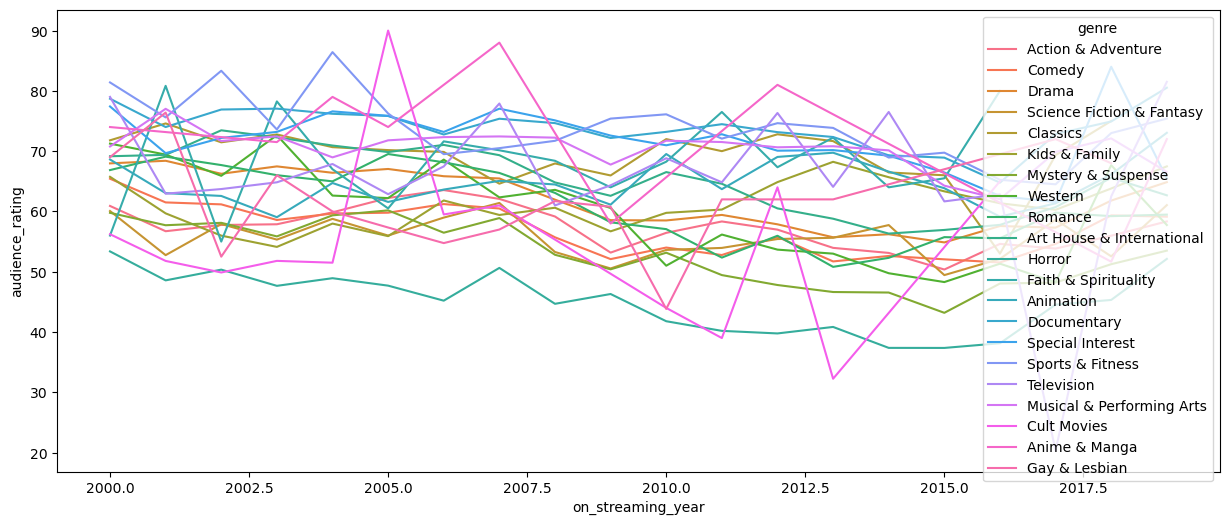

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))

# Checking the average ratings of movies in the 21st century as an example of presenting the data
sns.lineplot(data = df2[df2['on_streaming_year'] >= 2000], \
             x = 'on_streaming_year', y = 'audience_rating', \
             hue = 'genre', ax=ax, errorbar=None)

<Axes: >

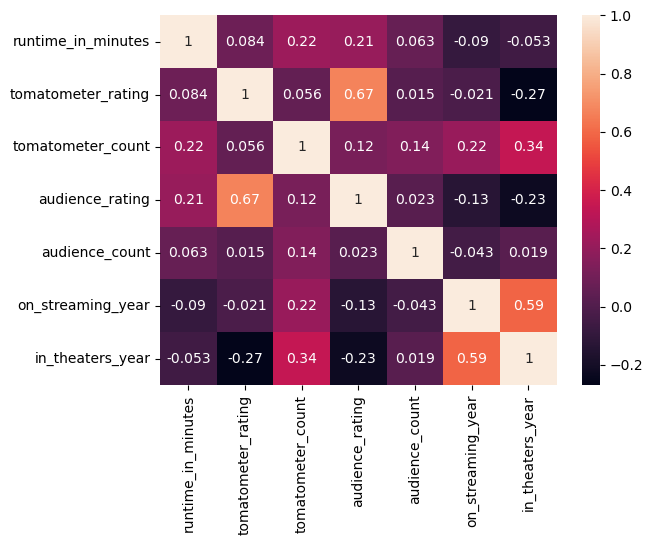

In [16]:
# Checking for potential correlation
sns.heatmap(data = df2.corr(numeric_only = True), annot = True)

In [17]:
# One last check before the exportation
df2

,movie_title,rating,genre,in_theaters_date,on_streaming_date,runtime_in_minutes,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,on_streaming_year,in_theaters_year
0,Percy Jackson & the Olympians: The Lightning T...,PG,Action & Adventure,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Comedy,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Drama,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
0,Percy Jackson & the Olympians: The Lightning T...,PG,Science Fiction & Fantasy,2010-12-02,2010-06-29,83.00,Rotten,49.00,144.00,53.00,"254,287.00",2010,"2,010.00"
1,Please Give,R,Comedy,2010-04-30,2010-10-19,90.00,Certified Fresh,86.00,140.00,64.00,"11,567.00",2010,"2,010.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16384,Zulu,PG,Classics,1964-06-17,2001-02-02,139.00,Fresh,95.00,21.00,91.00,"30,170.00",2001,"1,964.00"
16384,Zulu,PG,Drama,1964-06-17,2001-02-02,139.00,Fresh,95.00,21.00,91.00,"30,170.00",2001,"1,964.00"
16385,Zulu Dawn,PG,Action & Adventure,1979-12-14,2005-09-27,117.00,Rotten,57.00,7.00,62.00,"4,464.00",2005,"1,979.00"
16385,Zulu Dawn,PG,Art House & International,1979-12-14,2005-09-27,117.00,Rotten,57.00,7.00,62.00,"4,464.00",2005,"1,979.00"


In [18]:
# Exporting the remade dataframe
df2.to_csv(r'C:\Users\Rosny\Desktop\Movie Ratings Project\fixed_movie_rating_data.csv', index=False)

In [22]:
df['audience_count']

movie_title           30569
rating                30569
genre                 30569
in_theaters_date      30569
on_streaming_date     30569
runtime_in_minutes    30355
tomatometer_status    30569
tomatometer_rating    30569
tomatometer_count     30569
audience_rating       30569
audience_count        30569
on_streaming_year     30569
in_theaters_year      30569
dtype: int64